<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/Fuel_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Untuk melihat waktu jalan coding nya**

In [7]:
import time

# Start the timer for the entire code execution
start_time_total = time.time()

Tambahkan kode di bawah ini di bagian yang ingin Anda ukur waktu eksekusinya, misalnya saat memuat library atau melatih model.

In [8]:
# Example: Measuring time for library import (this is just for demonstration)
start_time_library = time.time()
# import your library here
end_time_library = time.time()
print(f"Time taken for library import: {end_time_library - start_time_library:.4f} seconds")

# Example: Measuring time for model training (add your model training code here)
# start_time_model = time.time()
# # your model training code
# end_time_model = time.time()
# print(f"Time taken for model training: {end_time_model - start_time_model:.4f} seconds")

Time taken for library import: 0.0001 seconds


In [9]:
# End the timer for the entire code execution
end_time_total = time.time()
print(f"Total execution time: {end_time_total - start_time_total:.4f} seconds")

Total execution time: 0.0112 seconds


**A. Persiapan & Load Dataset**

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

**Membaca data set dan cleaning**

In [11]:
data = pd.read_csv("FuelConsumption.csv")

# Menghapus kolom yang tidak diinginkan
columns_to_drop = ['MODEL', 'TRANSMISSION', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'VEHICLECLASS', 'MAKE']

# Mengubah kolom 'FUELTYPE' menjadi numerik menggunakan label encoding (sesuai urutan abjad)
data['FUELTYPE'] = data['FUELTYPE'].astype('category').cat.codes


print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nStatistik deskriptif:")
display(data.describe(include='all'))

print("\nChecking for missing values:")
print(data.isnull().sum())

Preview data:


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,3,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,3,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,3,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,3,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,3,12.1,8.7,10.6,27,244



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   int8   
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), int8(1), object(4)
memory

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067,1067,1067,1067.000000,1067.000000,1067,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
unique,NaN,39,663,16,NaN,NaN,22,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,FORD,F150 FFV 4X4,MID-SIZE,NaN,NaN,A6,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,90,8,178,NaN,NaN,222,NaN,NaN,NaN,NaN,NaN,NaN
mean,2014.0,NaN,NaN,NaN,3.346298,5.794752,NaN,2.269916,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,NaN,NaN,NaN,1.415895,1.797447,NaN,0.722374,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,NaN,NaN,NaN,1.000000,3.000000,NaN,0.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,NaN,NaN,NaN,2.000000,4.000000,NaN,2.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,NaN,NaN,NaN,3.400000,6.000000,NaN,2.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,NaN,NaN,NaN,4.300000,8.000000,NaN,3.000000,15.550000,10.850000,13.350000,31.000000,294.000000



Checking for missing values:
MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64


**Encoding Kategorikal**

In [19]:
# Melakukan one-hot encoding pada kolom 'FUELTYPE'
data_encoded = pd.get_dummies(data, columns=['FUELTYPE'], drop_first=True)

print("Preview data setelah one-hot encoding:")
display(data_encoded.head())

print("\nInfo data setelah one-hot encoding:")
print(data_encoded.info())

Preview data setelah one-hot encoding:


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,FUELTYPE_1,FUELTYPE_2,FUELTYPE_3
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,9.9,6.7,8.5,33,196,False,False,True
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,11.2,7.7,9.6,29,221,False,False,True
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,6.0,5.8,5.9,48,136,False,False,True
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,12.7,9.1,11.1,25,255,False,False,True
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,12.1,8.7,10.6,27,244,False,False,True



Info data setelah one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELCONSUMPTION_CITY      1067 non-null   float64
 8   FUELCONSUMPTION_HWY       1067 non-null   float64
 9   FUELCONSUMPTION_COMB      1067 non-null   float64
 10  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 11  CO2EMISSIONS              1067 non-null   int64  
 12  FUELTYPE_1                1067 non-null   bool   
 13  FUELTYPE_2                

**Menghitung dan memvisualisasikan matriks korelasi**

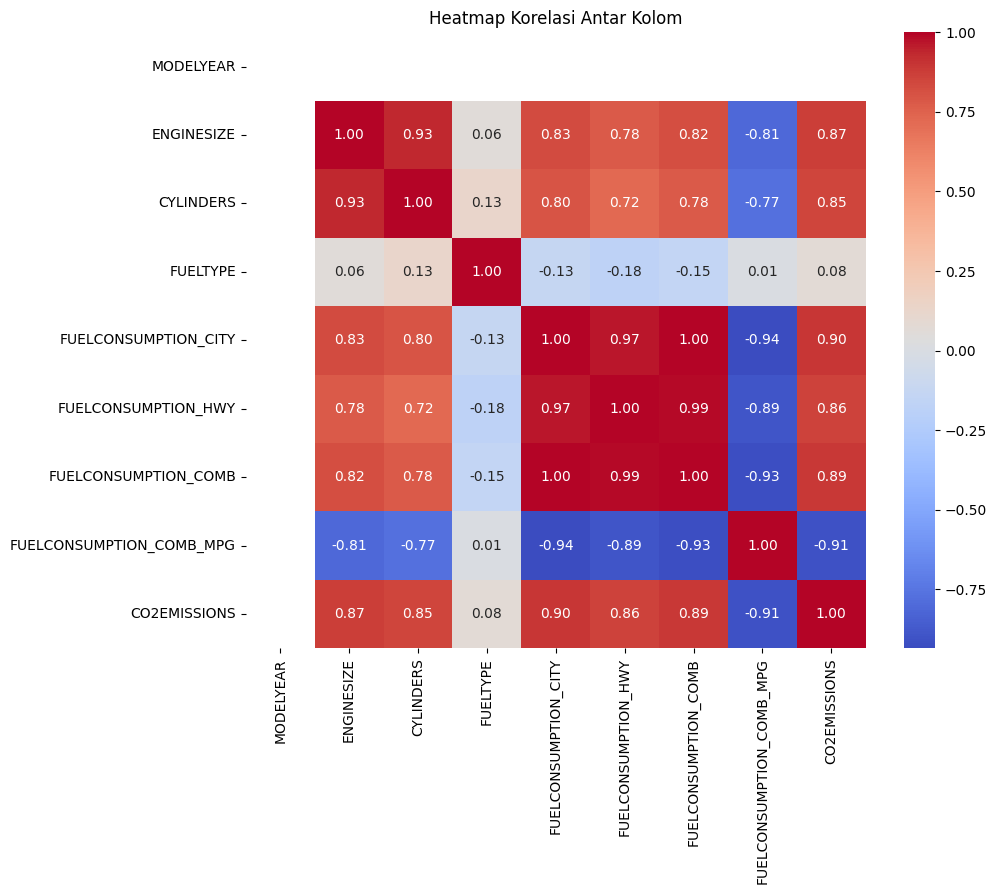

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung matriks korelasi
# Ensure non-numeric columns are dropped for correlation calculation
correlation_matrix = data.drop(columns=['MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION']).corr()


# Tampilkan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Antar Kolom')
plt.show()

**Exploratory Data Analysis (EDA)**

In [14]:
# Hitung korelasi dengan kolom 'CO2EMISSIONS'
# Pastikan kolom non-numerik yang tidak diinginkan dihapus sebelum menghitung korelasi
correlation_with_co2 = data.drop(columns=['FUELTYPE', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION']).corr()['CO2EMISSIONS'].sort_values(ascending=False)

print("Korelasi dengan CO2EMISSIONS:")
print(correlation_with_co2)

Korelasi dengan CO2EMISSIONS:
CO2EMISSIONS                1.000000
FUELCONSUMPTION_CITY        0.898039
FUELCONSUMPTION_COMB        0.892129
ENGINESIZE                  0.874154
FUELCONSUMPTION_HWY         0.861748
CYLINDERS                   0.849685
FUELCONSUMPTION_COMB_MPG   -0.906394
MODELYEAR                        NaN
Name: CO2EMISSIONS, dtype: float64


**Pisahkan Fitur & Target**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (853, 4)
Shape of X_test: (214, 4)
Shape of y_train: (853,)
Shape of y_test: (214,)


In [18]:
features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG']
X = data[features]
y = data['CO2EMISSIONS']

print("Preview data features (X):")
display(X.head())

print("\nPreview data target (y):")
display(y.head())

Preview data features (X):


,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG
0,2.0,4,8.5,33
1,2.4,4,9.6,29
2,1.5,4,5.9,48
3,3.5,6,11.1,25
4,3.5,6,10.6,27



Preview data target (y):


,CO2EMISSIONS
0,196
1,221
2,136
3,255
4,244


**Bangun Model Linear Regression**

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
print("Linear regression model successfully built and evaluated.")

Linear regression model successfully built and evaluated.


**Evaluasi Model**

In [34]:
y_pred = model.predict(X_test)

In [35]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

R-squared: 0.9023
Mean Absolute Error (MAE): 12.9594
Mean Squared Error (MSE): 404.0962


**Visualisasi Hasil Prediksi**

In [36]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Contoh prediksi vs aktual:")
for i in range(5):
    print(f"Prediksi: {round(y_pred[i],2)}  |  Aktual: {y_test.iloc[i]}")

Contoh prediksi vs aktual:
Prediksi: 308.44  |  Aktual: 304
Prediksi: 243.3  |  Aktual: 221
Prediksi: 280.64  |  Aktual: 294
Prediksi: 238.69  |  Aktual: 221
Prediksi: 207.38  |  Aktual: 207


**Cek Residuals**

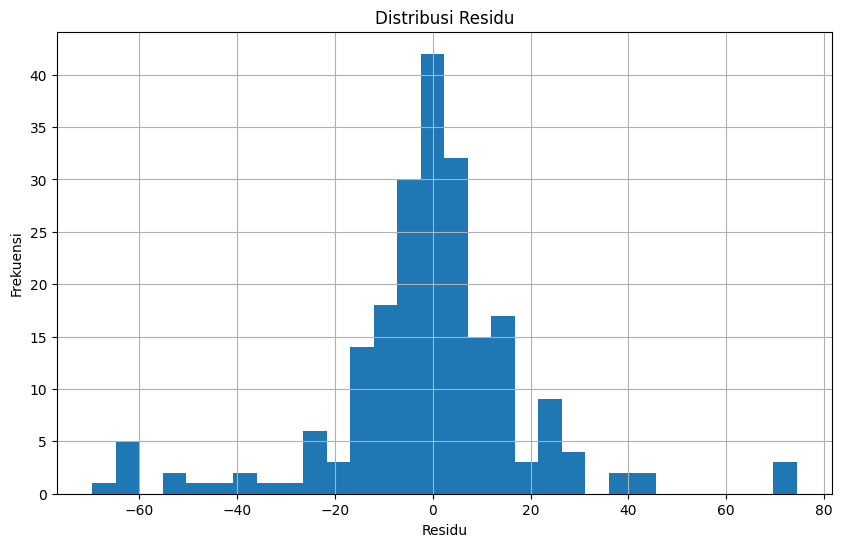

In [38]:
import matplotlib.pyplot as plt

# Hitung residu
residuals = y_test - y_pred

# Buat histogram residu
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30)
plt.xlabel("Residu")
plt.ylabel("Frekuensi")
plt.title("Distribusi Residu")
plt.grid(True)
plt.show()

**Feature Importance (Koefisien)**

In [33]:
# Dapatkan nama fitur dari X_train
feature_names = X_train.columns

# Dapatkan koefisien dari model
coefficients = model.coef_

# Buat DataFrame untuk koefisien dan nama fitur
coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Urutkan koefisien berdasarkan nilai absolutnya
coefficients_df['Abs_Coefficient'] = abs(coefficients_df['Coefficient'])
top_coefficients = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)

print("Top 15 Coefficients:")
display(top_coefficients[['Feature', 'Coefficient']])

Top 15 Coefficients:


,Feature,Coefficient
0,ENGINESIZE,9.214544
1,CYLINDERS,6.319751
3,FUELCONSUMPTION_COMB_MPG,-3.814032
2,FUELCONSUMPTION_COMB,3.037676


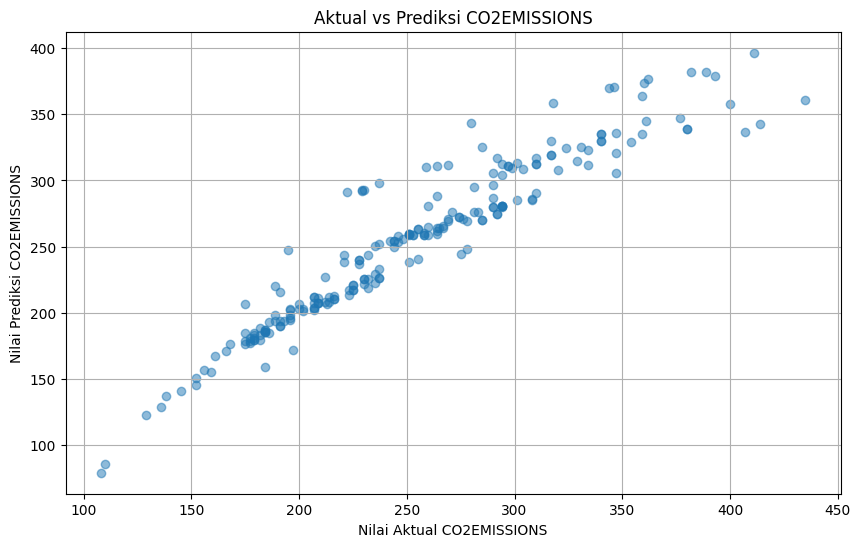

In [37]:
import matplotlib.pyplot as plt

# Buat scatter plot prediksi vs aktual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Nilai Aktual CO2EMISSIONS")
plt.ylabel("Nilai Prediksi CO2EMISSIONS")
plt.title("Aktual vs Prediksi CO2EMISSIONS")
plt.grid(True)
plt.show()

**Menampilkan kembali metrik evaluasi dari model regresi linear yang telah Anda latih dan evaluasi sebelumnya.**

In [39]:
# Metrik evaluasi sudah dihitung di sel 434f554b
# Menampilkan kembali hasil evaluasi
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

R-squared: 0.9023
Mean Absolute Error (MAE): 12.9594
Mean Squared Error (MSE): 404.0962


**Visualisasi hasil prediksi**

Mobil denga CO2EMISSIONS tertinggi

In [40]:
# Cari baris dengan CO2EMISSIONS tertinggi
max_co2_row = data.loc[data['CO2EMISSIONS'].idxmax()]

print(f"Make dan Model dengan CO2EMISSIONS tertinggi:")
print(f"Make: {max_co2_row['MAKE']}")
print(f"Model: {max_co2_row['MODEL']}")
print(f"CO2EMISSIONS tertinggi: {max_co2_row['CO2EMISSIONS']}")

Make dan Model dengan CO2EMISSIONS tertinggi:
Make: FORD
Model: E350 WAGON
CO2EMISSIONS tertinggi: 488


/tmp/ipython-input-3965448949.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes_max_co2.index, y=top_makes_max_co2.values, palette='viridis')


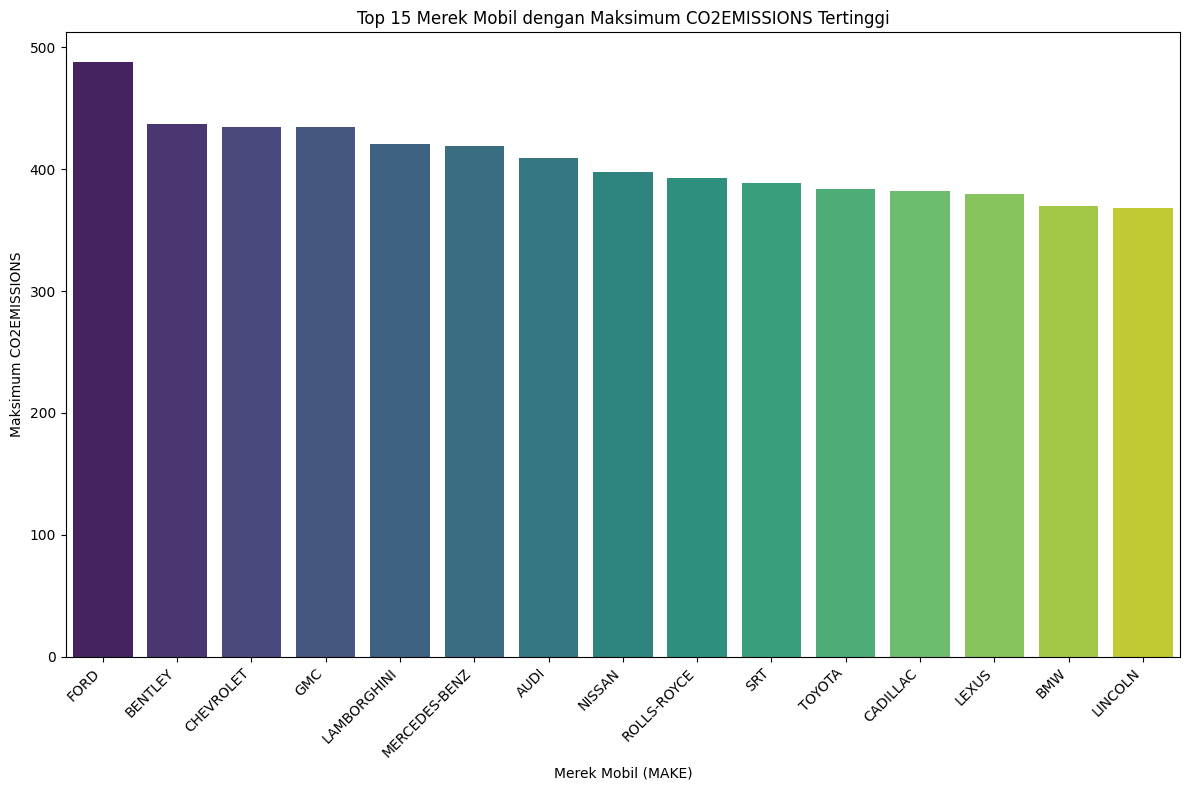

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung maksimum CO2EMISSIONS per Make
max_co2_per_make = data.groupby('MAKE')['CO2EMISSIONS'].max().sort_values(ascending=False)

# Pilih top N makes untuk visualisasi (misalnya top 15)
top_n = 15
top_makes_max_co2 = max_co2_per_make.head(top_n)

# Buat bar plot dari maksimum CO2EMISSIONS per Make
plt.figure(figsize=(12, 8))
sns.barplot(x=top_makes_max_co2.index, y=top_makes_max_co2.values, palette='viridis')
plt.xlabel("Merek Mobil (MAKE)")
plt.ylabel("Maksimum CO2EMISSIONS")
plt.title(f"Top {top_n} Merek Mobil dengan Maksimum CO2EMISSIONS Tertinggi")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Memberikan wawasan lebih lanjut tentang karakteristik (ukuran mesin, jumlah silinder, konsumsi bahan bakar) dari kendaraan yang menghasilkan emisi CO2 paling banyak, yang dapat membantu dalam memahami faktor-faktor yang berkontribusi terhadap emisi tinggi.

In [42]:
# Identifikasi baris dengan CO2EMISSIONS tertinggi (sudah dilakukan di sel 21ad312f)
max_co2_row = data.loc[data['CO2EMISSIONS'].idxmax()]

print(f"Kendaraan dengan CO2EMISSIONS tertinggi: {max_co2_row['MAKE']} {max_co2_row['MODEL']}")
print(f"CO2EMISSIONS tertinggi: {max_co2_row['CO2EMISSIONS']}")

# Tampilkan nilai fitur-fitur yang berkorelasi kuat untuk kendaraan ini
print("\nNilai Fitur Utama untuk Kendaraan dengan CO2EMISSIONS Tertinggi:")
features_to_examine = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG']
for feature in features_to_examine:
    if feature in max_co2_row:
        print(f"- {feature}: {max_co2_row[feature]}")
    else:
        print(f"- {feature}: Kolom tidak tersedia di data saat ini.")

# Optionally, compare with average feature values across the dataset
# print("\nRata-rata Nilai Fitur di Seluruh Dataset:")
# for feature in features_to_examine:
#     if feature in data.columns:
#          print(f"- {feature}: {data[feature].mean():.2f}")
#     else:
#          print(f"- {feature}: Kolom tidak tersedia di data saat ini.")

Kendaraan dengan CO2EMISSIONS tertinggi: FORD E350 WAGON
CO2EMISSIONS tertinggi: 488

Nilai Fitur Utama untuk Kendaraan dengan CO2EMISSIONS Tertinggi:
- ENGINESIZE: 6.8
- CYLINDERS: 10
- FUELCONSUMPTION_COMB: 21.2
- FUELCONSUMPTION_COMB_MPG: 13


**Memvisualisasikan hubungan antara beberapa fitur utama**

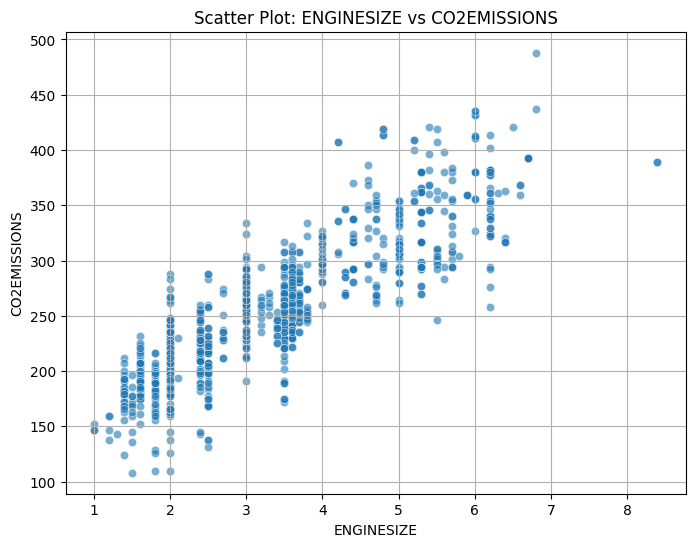

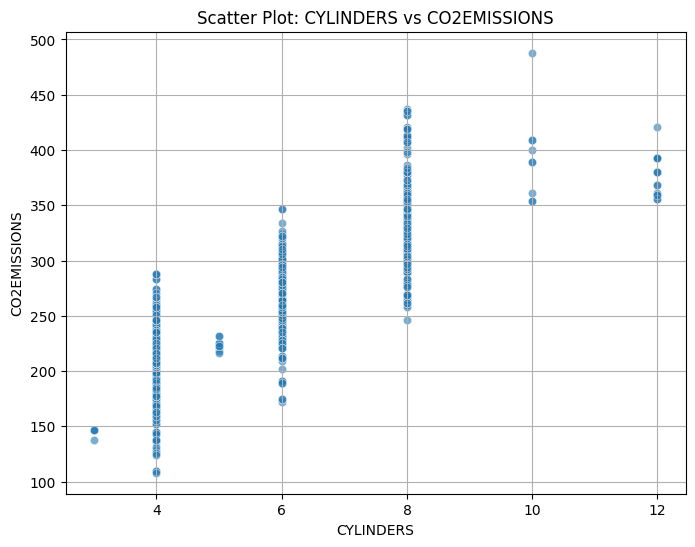

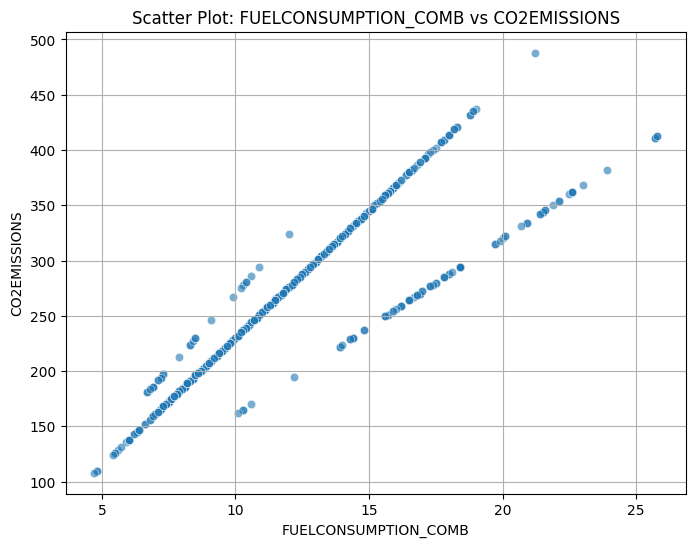

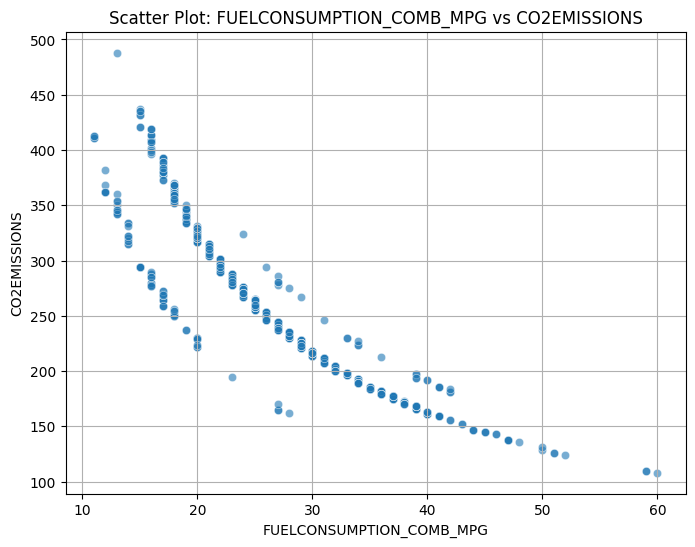

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG']

for feature in features_to_plot:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=data[feature], y=data['CO2EMISSIONS'], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel("CO2EMISSIONS")
    plt.title(f"Scatter Plot: {feature} vs CO2EMISSIONS")
    plt.grid(True)
    plt.show()

**Simpan Model dan Deploy**

In [49]:
import gradio as gr
import pandas as pd

# Asumsi: model dan features sudah tersedia
# model = LinearRegression()
# features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG']

def predict_co2(enginesize, cylinders, fuelconsumption_comb, fuelconsumption_comb_mpg):
    # Pastikan semua input menjadi float
    input_df = pd.DataFrame({
        'ENGINESIZE': [float(enginesize)],
        'CYLINDERS': [float(cylinders)],
        'FUELCONSUMPTION_COMB': [float(fuelconsumption_comb)],
        'FUELCONSUMPTION_COMB_MPG': [float(fuelconsumption_comb_mpg)]
    })
    input_df = input_df[features]

    prediction = model.predict(input_df)

    # Kembalikan hasil sebagai string biasa agar textbox tidak menampilkan spinner/flag
    return f"{prediction[0]:.2f} g/km CO2"

demo = gr.Interface(
    fn=predict_co2,
    inputs=[
        gr.Textbox(label="Engine Size", placeholder="Masukkan engine size"),
        gr.Textbox(label="Cylinders", placeholder="Masukkan jumlah silinder"),
        gr.Textbox(label="Fuel Consumption Combined (L/100 km)", placeholder="Masukkan konsumsi bahan bakar"),
        gr.Textbox(label="Fuel Consumption Combined (MPG)", placeholder="Masukkan konsumsi bahan bakar (MPG)"),
    ],
    outputs=gr.Textbox(label="Predicted CO2 Emissions", type="text"),  # pastikan type=text
    title="🚗 CO2 Emissions Prediction App",
    description="Masukkan spesifikasi kendaraan untuk memprediksi emisi CO2.",
    theme="soft"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://991ff0b79b827f5b28.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
